In [9]:
import functions as func
import os
import pandas as pd
import geopandas as gpd
import plotly.express as px
import ast
import numpy as np
%pylab inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 40000)
pd.set_option('display.max_rows', None)

#df_safegraph_poi = pd.read_csv(os.path.join('..', 'dewey_data_filtered','SafeGraph_POI_Yellowstone_200miRadius.csv.gz'))
#df_safegraph_spend = pd.read_csv(os.path.join('..', 'dewey_data_filtered','SafeGraph_SPEND_Yellowstone_200miRadius.csv.gz'))

place = 'Cody'
df_safegraph_poi = pd.read_csv('SafeGraph_POI_Yellowstone_200miRadius.csv.gz')
df_safegraph_spend = pd.read_csv('SafeGraph_SPEND_Yellowstone_200miRadius.csv.gz')
#df_movement = pd.read_csv('')
before_flood_start = '2022-05-01'
before_flood_end = '2022-06-01'
during_flood_start = '2022-06-01'
during_flood_end = '2022-07-01'
after_flood_start = '2022-07-01'
after_flood_end = '2022-08-01'
month = ['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01', 
         '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01']
prev_months = ['2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', 
               '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-01']
naics_1 = '721'
TOS_1 = 'Accommodation'
naics_2 = '722'
TOS_2 = 'Food Service'
naics_3 = ['452', '445', '451', '448', '446']
TOS_3 = 'Retail Trade'
naics_4 = ['447', '485', '481']
TOS_4 = 'Transportation'
naics_5 = ['711', '712', '713']
TOS_5 = 'Arts, Entertainment, and Recreation'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\rexbo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['pie', 'place']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


## General Cody, WY

Here is unfiltered number of POIs 1526
Here is the total POIS 198


c:\Users\rexbo\OneDrive\Documents\SoC Worth\worth\notebooks\Spring2025\functions.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_place['NAICS_CODE_FINAL'] = df_place['NAICS_CODE'].astype(str).str[:2].map(lambda x: naics_to_group.get(x, 'Dump'))
c:\Users\rexbo\OneDrive\Documents\SoC Worth\worth\notebooks\Spring2025\functions.py:273: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()
c:\Users\rexbo\OneDrive\Documents\SoC Worth\worth\notebooks\Spring2025\functions.py:294: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

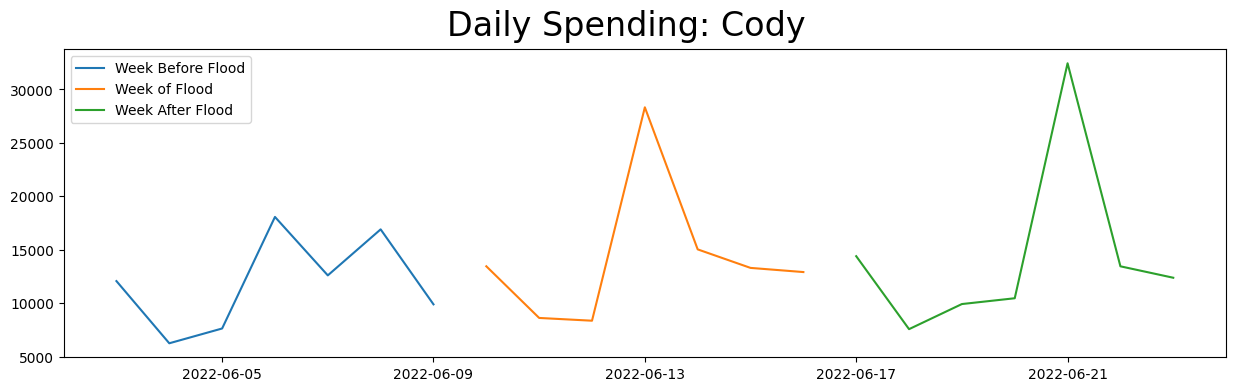

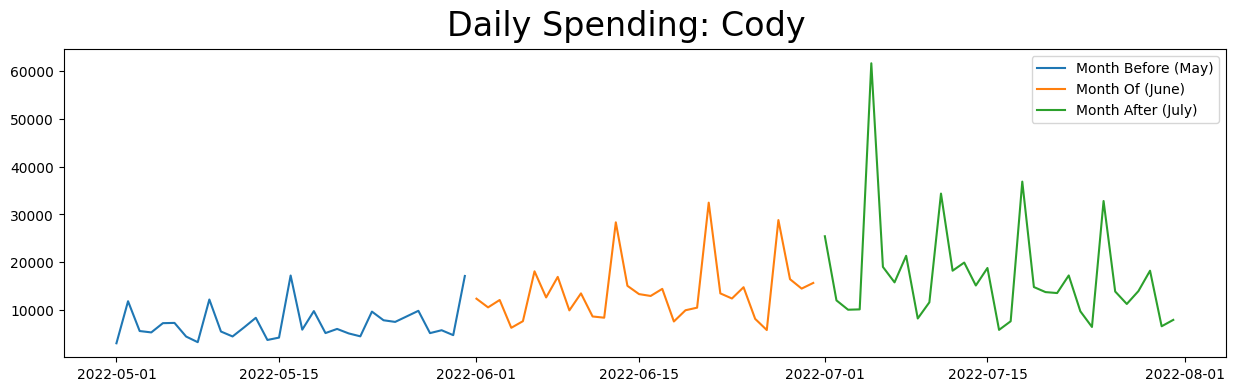

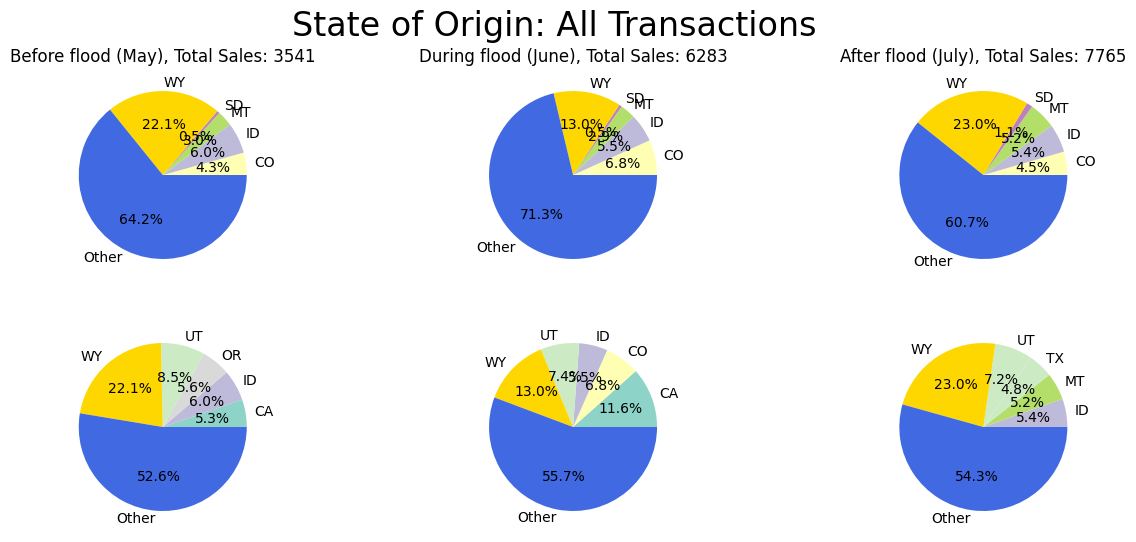

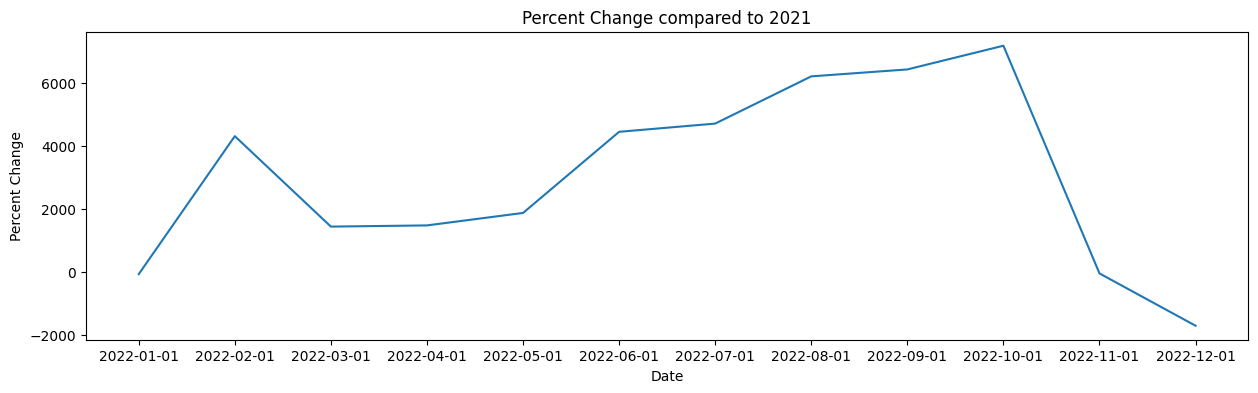

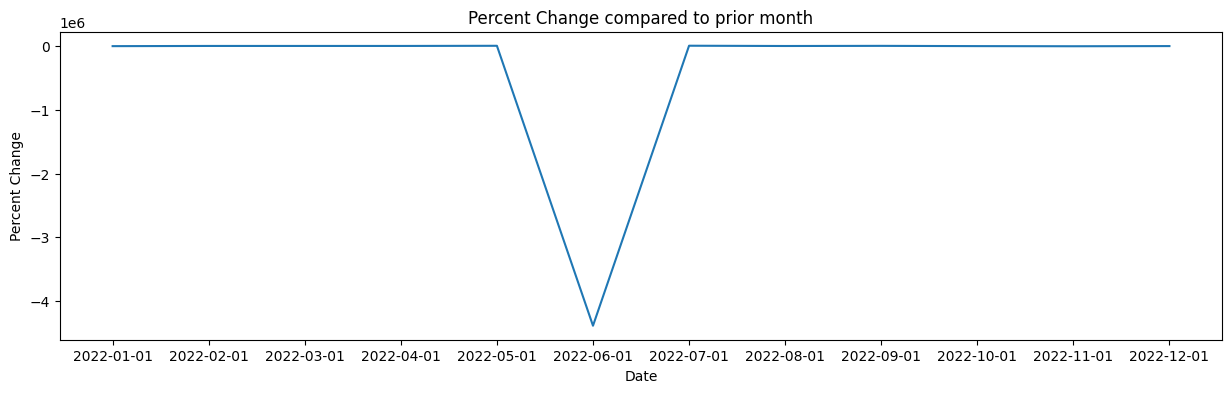

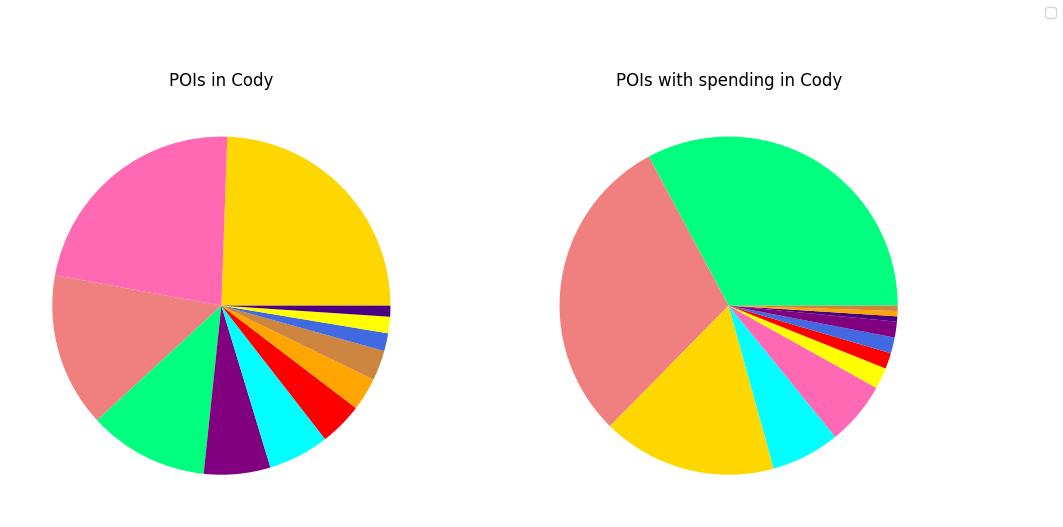

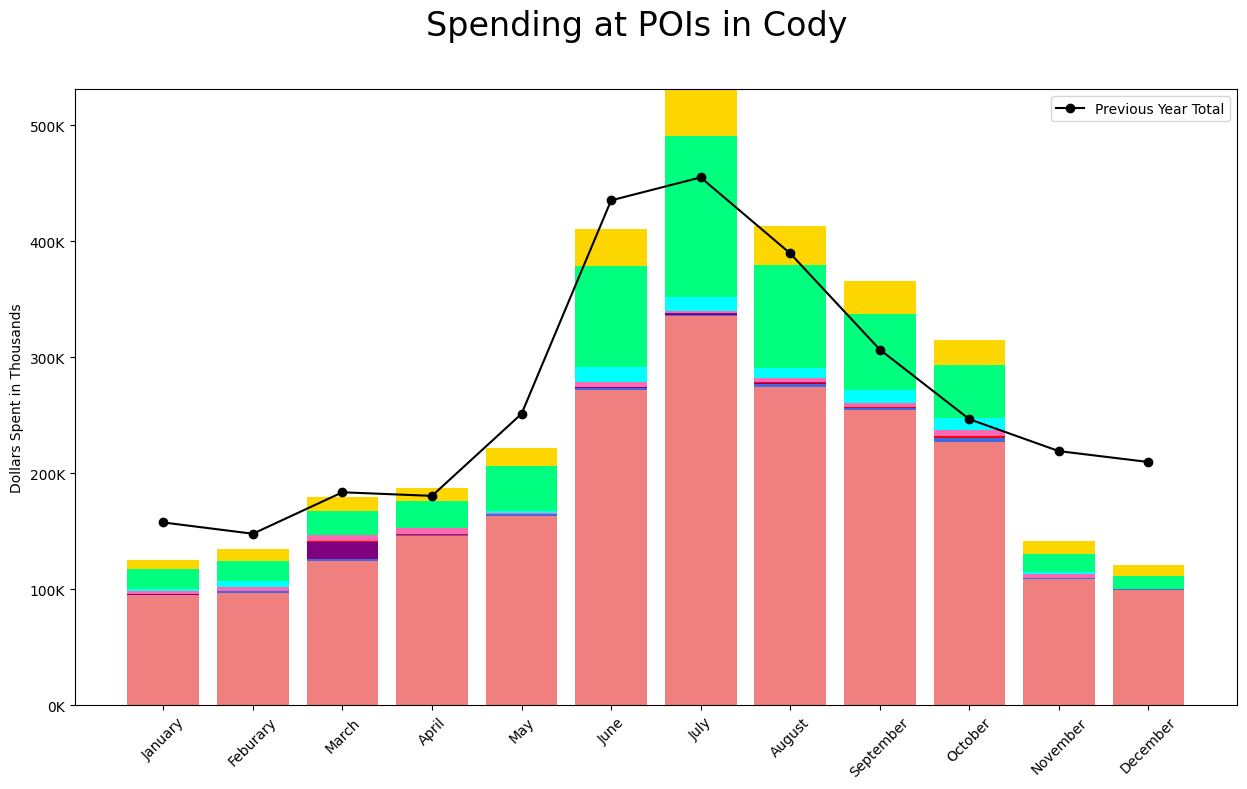

In [10]:
total = func.total_DS(place, df_safegraph_poi, df_safegraph_spend, before_flood_start, before_flood_end, 
                      during_flood_start, during_flood_end, after_flood_start, after_flood_end)
state = func.total_SOO(total[0][1], total[0][2], total[0][3])
func.total_Percent(total[0][0], month)
func.total_CSV(total[0][0], before_flood_start, after_flood_end, state[0], state[1], state[2], place)
pie = func.type_pie_town(df_safegraph_poi, df_safegraph_spend, place)
func.type_stacked_pie(df_safegraph_spend, pie[0], month, prev_months, place, pie[1])

## Cody Accomodations

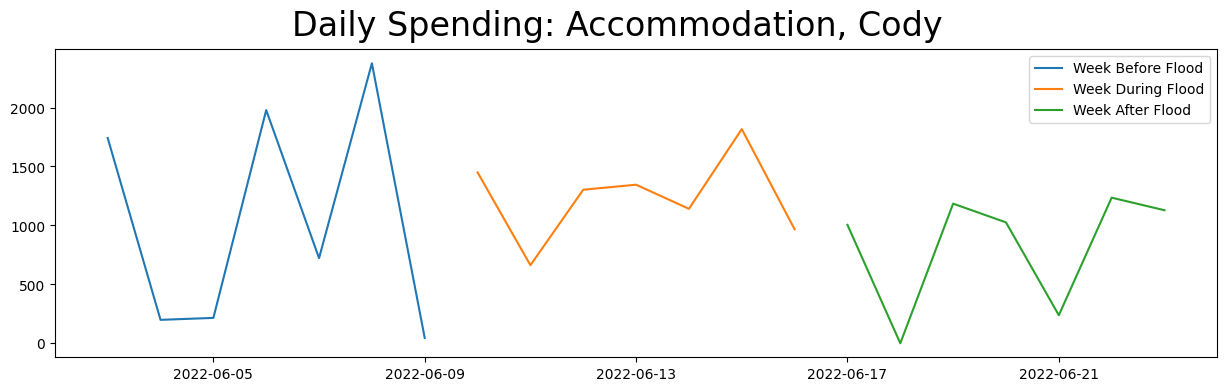

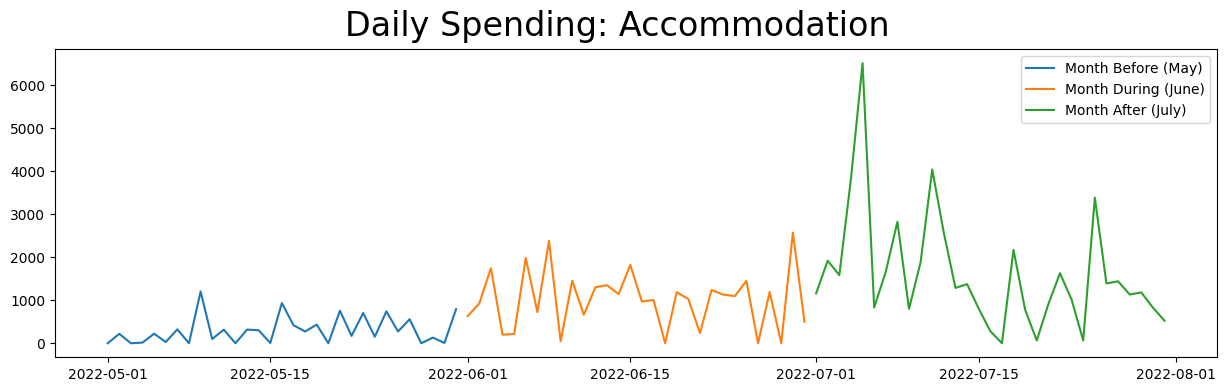

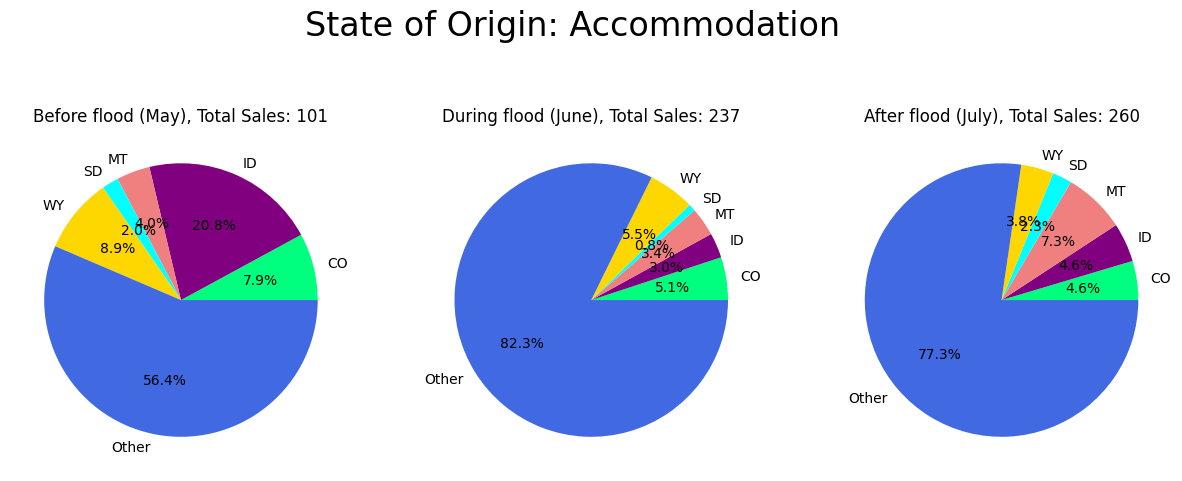

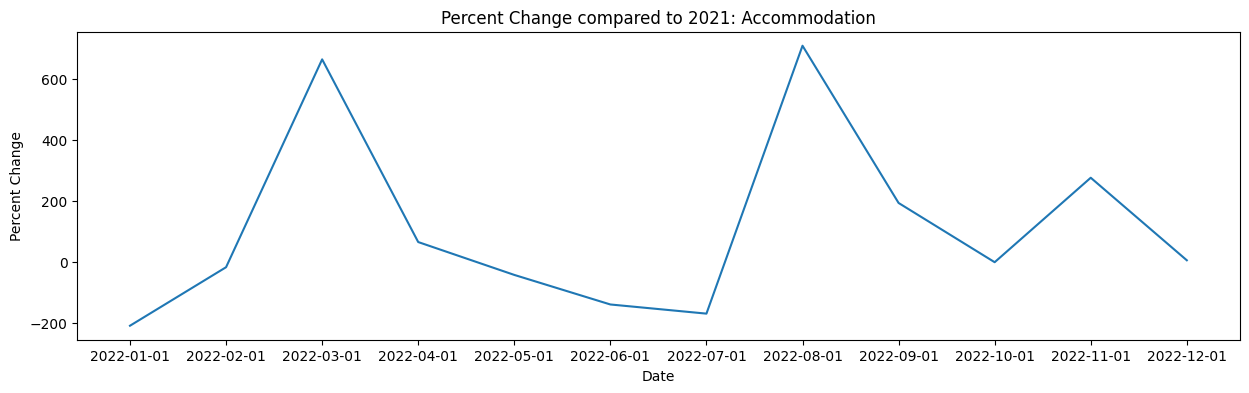

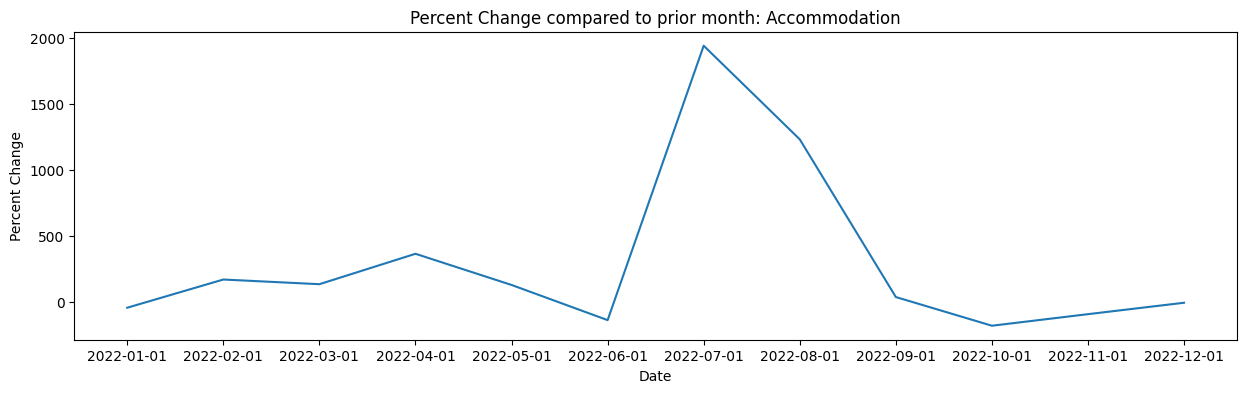

In [11]:
flood_accom = func.show_data_TOS(place, df_safegraph_poi, df_safegraph_spend, before_flood_start, before_flood_end, 
                during_flood_start, during_flood_end, after_flood_start, after_flood_end, month, 
                naics_1, TOS_1)

## Cody Food

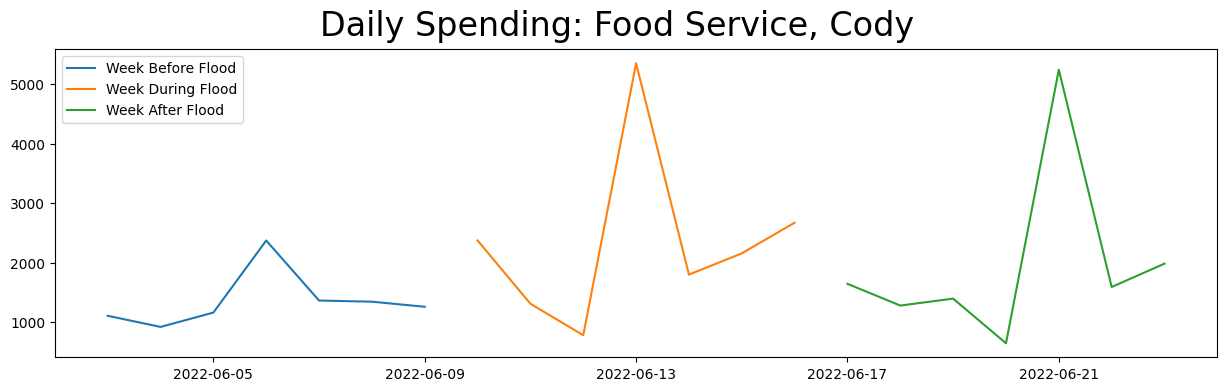

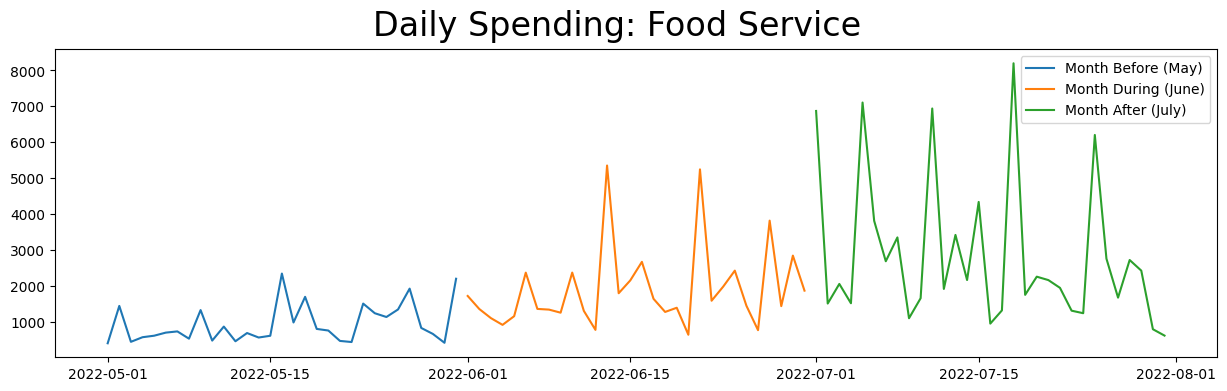

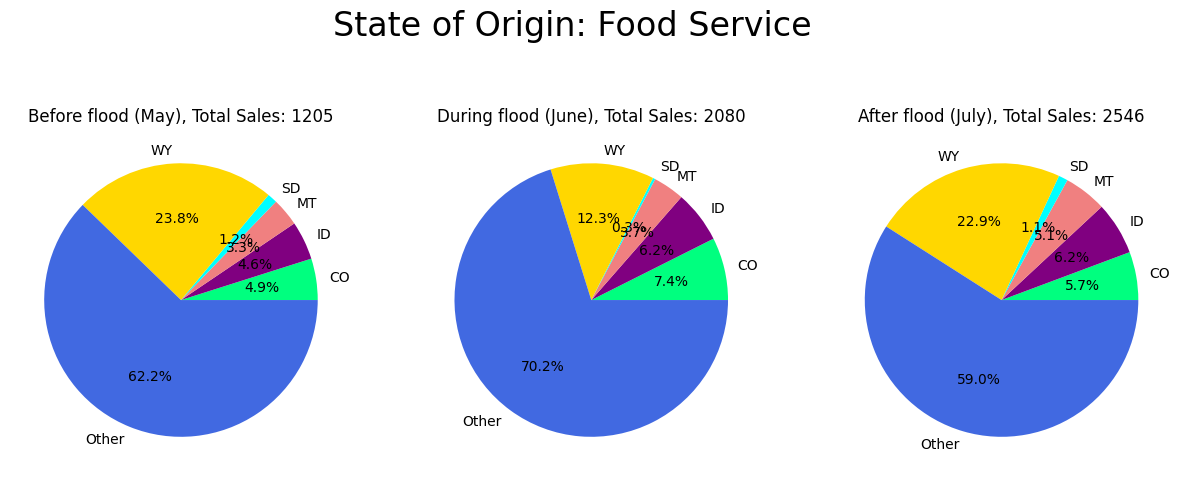

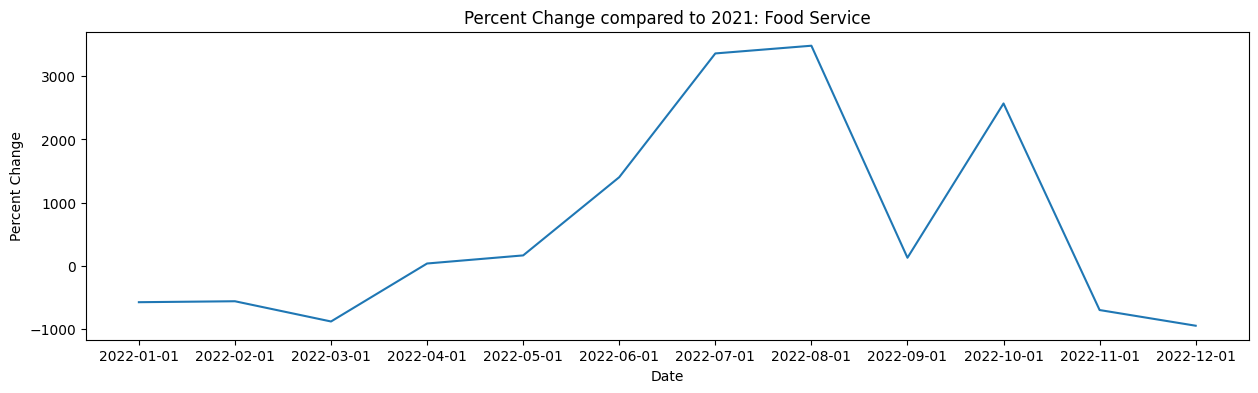

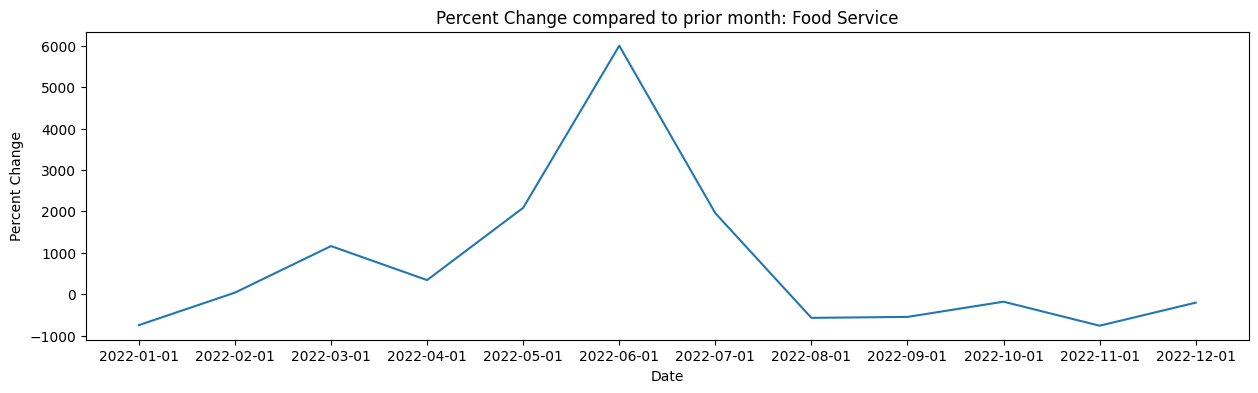

In [12]:
flood_food = func.show_data_TOS(place, df_safegraph_poi, df_safegraph_spend, before_flood_start, before_flood_end, 
                during_flood_start, during_flood_end, after_flood_start, after_flood_end, month, 
                naics_2, TOS_2)

## Cody Retail

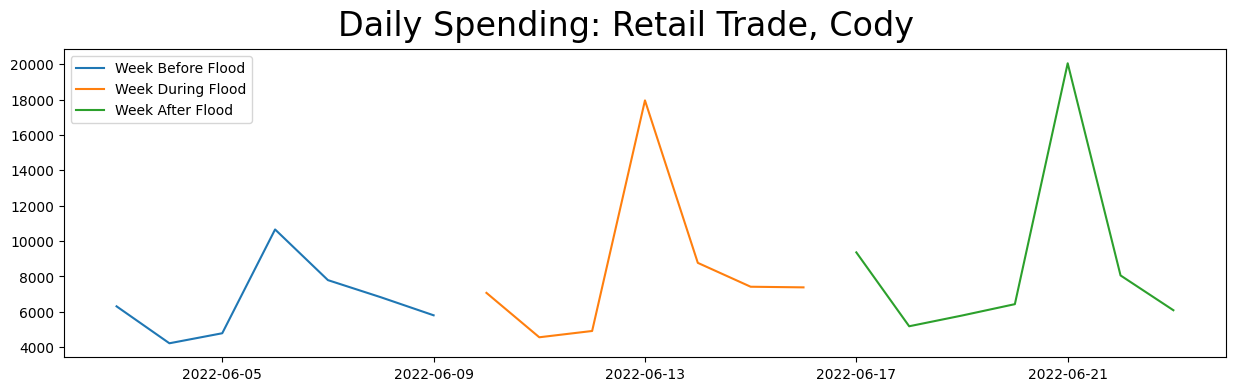

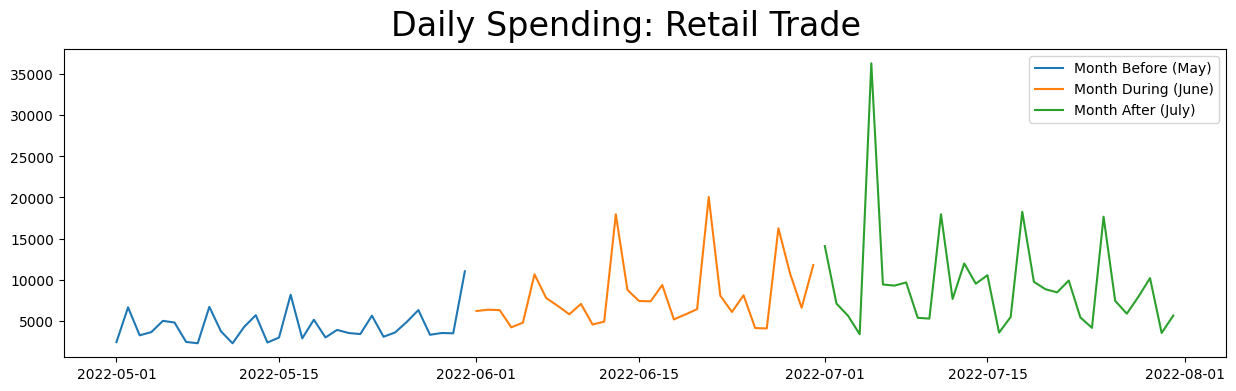

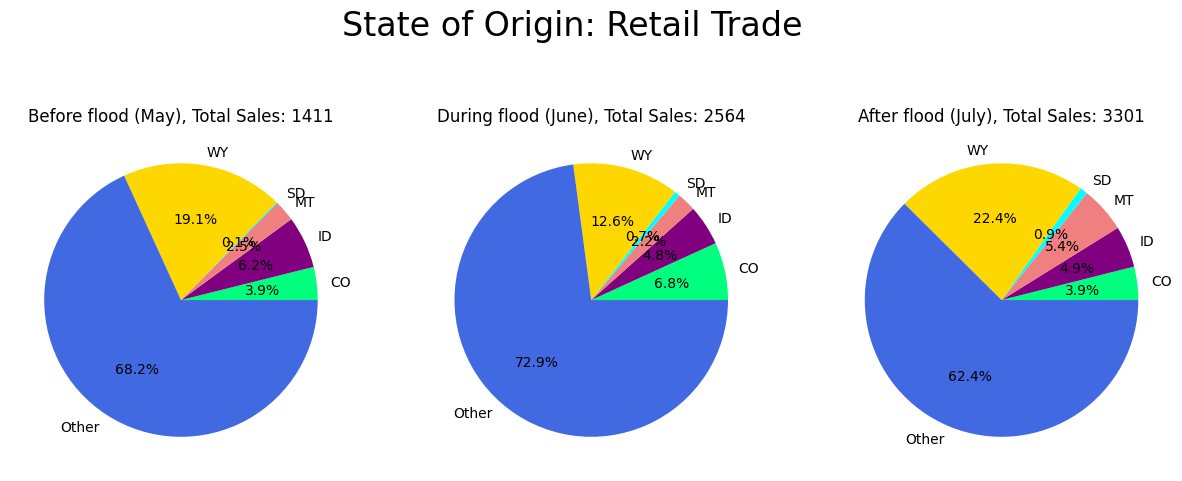

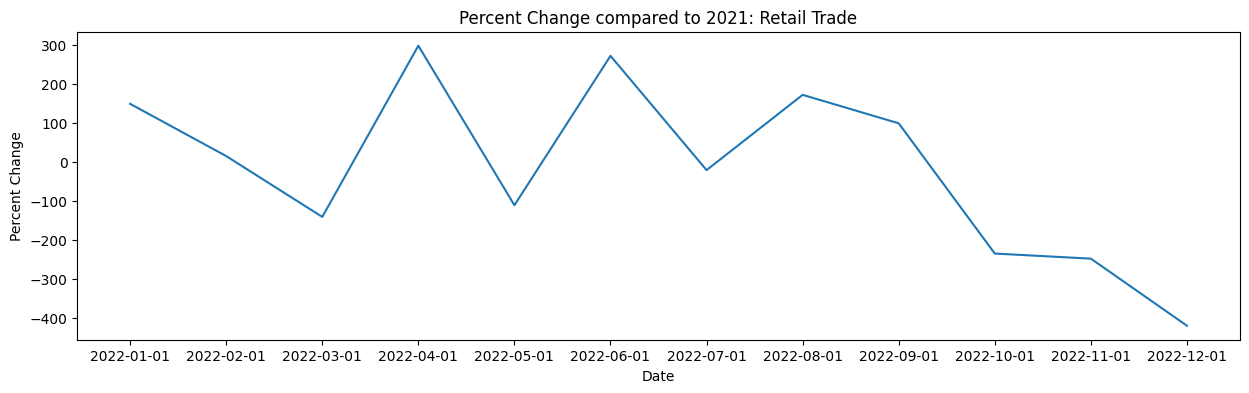

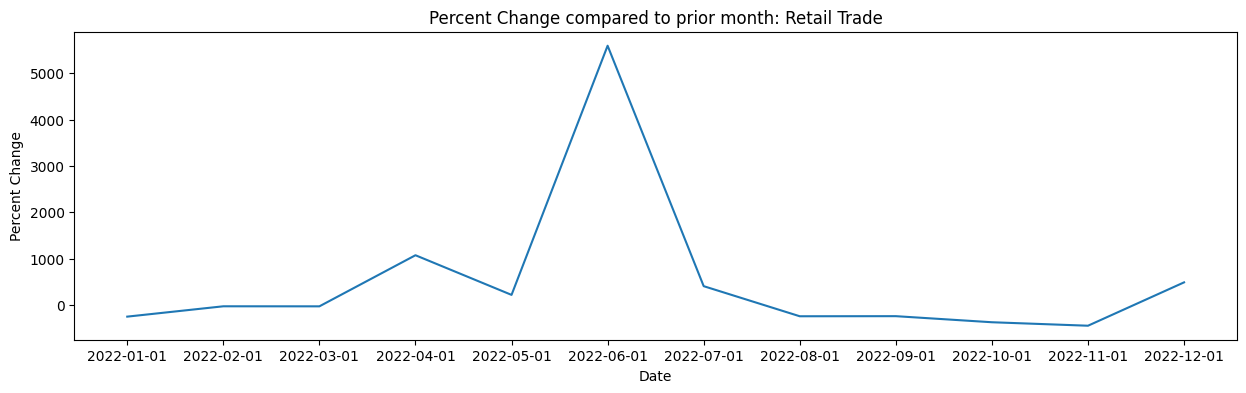

In [13]:
flood_retail = func.show_data_TOS(place, df_safegraph_poi, df_safegraph_spend, before_flood_start, before_flood_end, 
                during_flood_start, during_flood_end, after_flood_start, after_flood_end, month, 
                naics_3, TOS_3)

## Cody Transportation

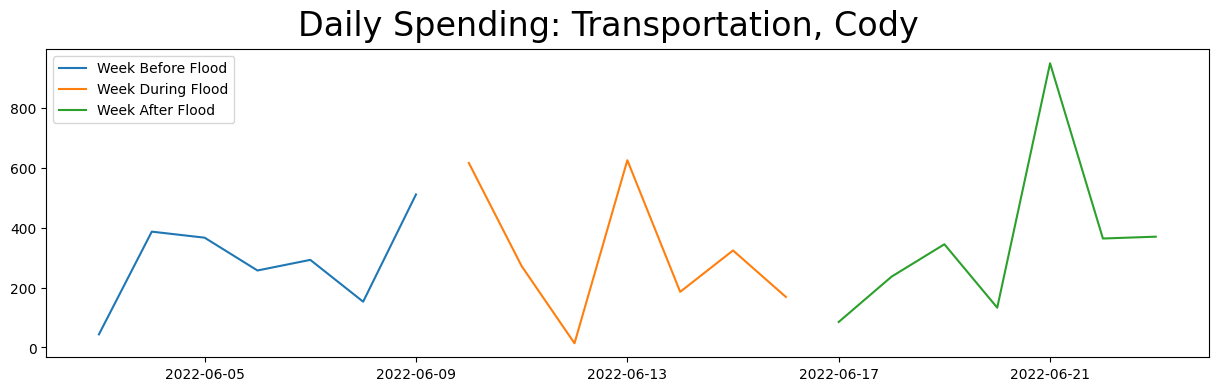

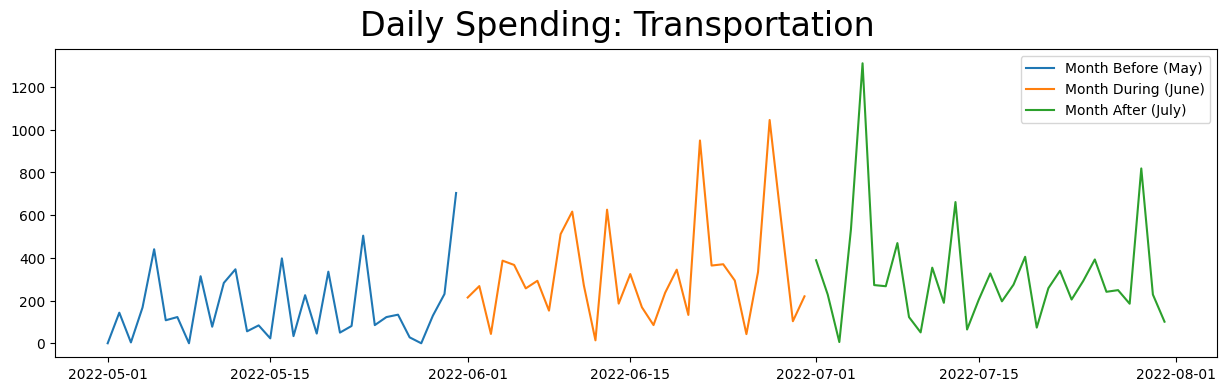

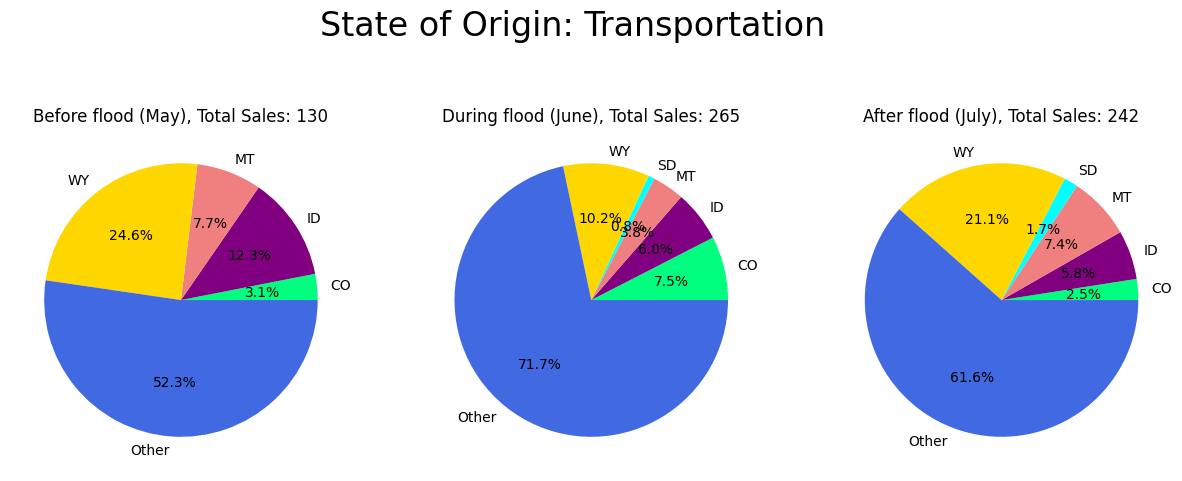

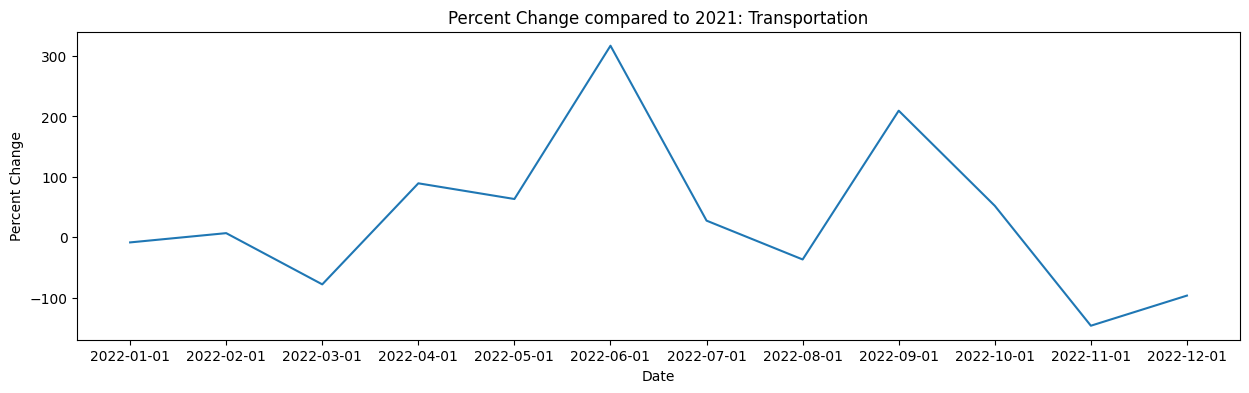

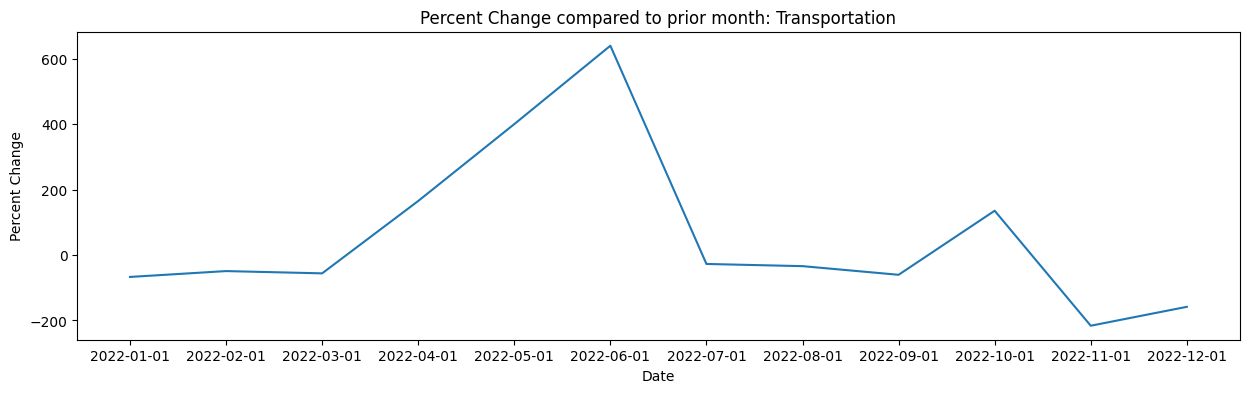

In [14]:
flood_transit = func.show_data_TOS(place, df_safegraph_poi, df_safegraph_spend, before_flood_start, before_flood_end, 
                during_flood_start, during_flood_end, after_flood_start, after_flood_end, month, 
                naics_4, TOS_4)

## Aggregate 

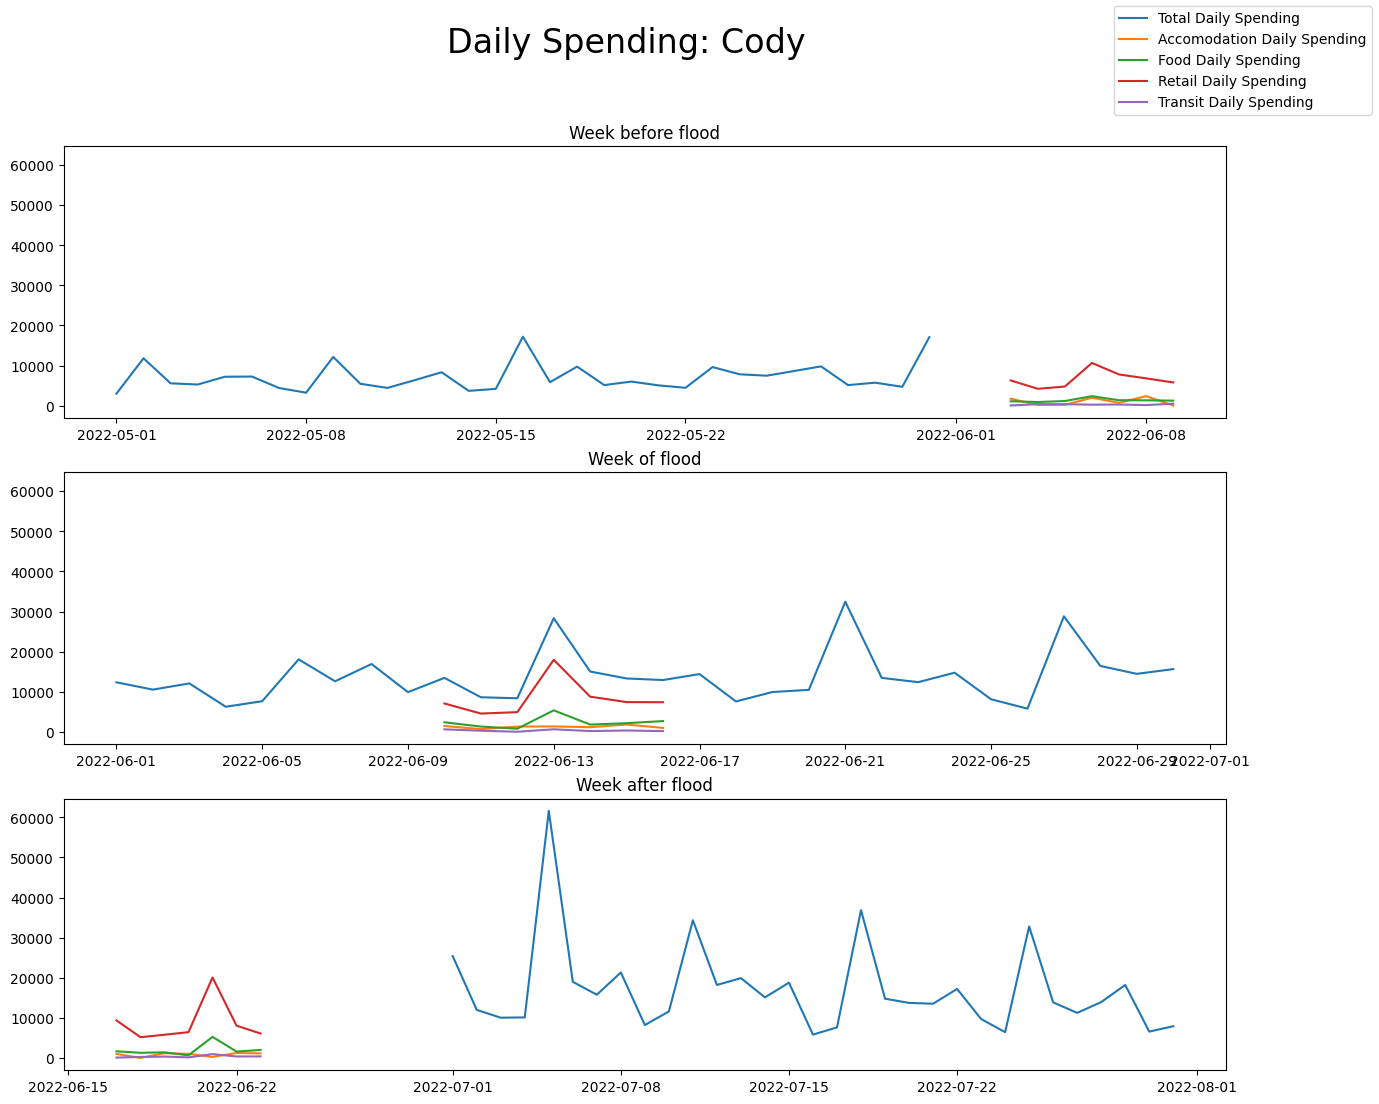

In [15]:
func.aggregate(total, flood_accom, flood_food, flood_retail, flood_transit, place)